#  Import Libraries

### Preprocessing Strategy and Justification

In traditional NLP pipelines, text normalization frequently includes removing stopwords, applying stemming or lemmatization, and reducing morphological variation. However, such practices are not suitable for transformer-based language models, since these models are pre-trained on natural, unaltered text and rely on full lexical and syntactic context to build contextual embeddings.

Applying stopword removal, stemming, or lemmatization would modify the token distribution and may introduce a distribution shift between the pre-training data and our downstream classification dataset, potentially degrading performance. Function words and morphological signals contribute to attention patterns and semantic disambiguation, and therefore should be preserved.

Accordingly, our preprocessing focuses only on light text normalization, namely:

- fixing LaTeX and HTML artifacts,

- removing duplicated whitespace,

- preserving the natural linguistic structure of the abstract.

- No stemming, lemmatization, or stopword removal is applied.

Supporting references:

Devlin, J. et al. (2019). BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding. https://arxiv.org/abs/1810.04805

Sanh, V. et al. (2019). DistilBERT: A distilled version of BERT. https://arxiv.org/abs/1910.01108

Bharadwaj, A. & Søgaard, A. (2020). On the Dangers of Stemming for Neural Language Models. https://arxiv.org/abs/2005.01704

In [11]:
from datasets import load_dataset, Dataset
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statistics
from transformers import AutoTokenizer
from collections import Counter
import re
import html
from datasets import DatasetDict

## Data Loading

In [4]:
# 1) Local load
PARQUET_FILE_PATH = r"C:\Users\ricar\Desktop\train.parquet"
df = pd.read_parquet(PARQUET_FILE_PATH)

# 2) Convert to HuggingFace Dataset
full_ds = Dataset.from_pandas(df, preserve_index=False)

# 3) Take a RANDOM subset of 100k examples
subset_size = 100_000
subset_size = min(subset_size, len(full_ds))

dataset = full_ds.shuffle(seed=42).select(range(subset_size))
print(f"Total examples in random subset: {len(dataset)}")

# 4) Keep only frequent labels in this subset
threshold = 2000  # at least 2,000 samples per label

counts = Counter(dataset["primary_subject"])
valid_labels = {label for label, cnt in counts.items() if cnt >= threshold}

filtered_ds = dataset.filter(lambda x: x["primary_subject"] in valid_labels)

print(f"\nFrequency threshold: {threshold}")
print(f"Number of labels kept: {len(valid_labels)}")
print("Kept labels and counts (within the 100k subset):")
for lab in sorted(valid_labels):
    print(f"{lab}: {counts[lab]}")

print(f"\nFiltered dataset size: {len(filtered_ds)}")


Total examples in random subset: 100000


Filter: 100%|██████████| 100000/100000 [00:01<00:00, 54044.77 examples/s]


Frequency threshold: 2000
Number of labels kept: 10
Kept labels and counts (within the 100k subset):
Analysis of PDEs (math.AP): 2026
Computation and Language (cs.CL): 2509
Computer Vision and Pattern Recognition (cs.CV): 4710
General Relativity and Quantum Cosmology (gr-qc): 2105
High Energy Physics - Phenomenology (hep-ph): 4496
High Energy Physics - Theory (hep-th): 3766
Machine Learning (cs.LG): 4151
Materials Science (cond-mat.mtrl-sci): 2635
Mesoscale and Nanoscale Physics (cond-mat.mes-hall): 2629
Quantum Physics (quant-ph): 4772

Filtered dataset size: 33799


### Class selection and random sub-sampling

In this step, we randomly selected 100,000 examples from the full arXiv training set and then kept only those `primary_subject` labels with at least 2,000 occurrences in this subset. This resulted in **10 labels** and **33,799 examples**, covering:

- Analysis of PDEs (math.AP)  
- Computation and Language (cs.CL)  
- Computer Vision and Pattern Recognition (cs.CV)  
- General Relativity and Quantum Cosmology (gr-qc)  
- High Energy Physics – Phenomenology (hep-ph)  
- High Energy Physics – Theory (hep-th)  
- Machine Learning (cs.LG)  
- Materials Science (cond-mat.mtrl-sci)  
- Mesoscale and Nanoscale Physics (cond-mat.mes-hall)  
- Quantum Physics (quant-ph)  

This preprocessing choice is motivated by three main reasons:

1. **Random sampling for representativeness**  
   Instead of taking the first 100k rows (which may be biased in time or subject), we shuffle the full dataset and then select 100k examples. This creates an approximately representative mini-corpus that preserves the overall subject distribution and avoids artefacts from ordering in the original file.

2. **Minimum frequency threshold for stable learning**  
   Requiring at least **2,000 occurrences per label** in the 100k subset ensures that each selected subject has enough data to train and evaluate a classifier reliably. Extremely rare labels would lead to unstable gradients, poor generalization, and misleading metrics. The threshold balances two goals:
   - remove underrepresented classes that are not suitable for this initial modeling stage;
   - retain a **multi-class setting** (10 subjects) that is still challenging and scientifically meaningful.

3. **Well-structured, diverse label set**  
   The surviving labels cover a broad spectrum of arXiv domains—computer science (cs.CL, cs.CV, cs.LG), mathematics (math.AP), condensed matter physics (cond-mat.*), high-energy and quantum physics (hep-ph, hep-th, quant-ph, gr-qc). This provides a **diverse but manageable** classification problem that is well aligned with the scientific structure observed in the data understanding phase.


 ## 3. Data Preprocessing

## 3.1 Clean text and build

In [7]:

print(filtered_ds)

def simple_clean(text: str) -> str:
    if not isinstance(text, str):
        return ""
    # 1) Decode HTML entities (e.g., &amp; -> &, &#39; -> ')
    text = html.unescape(text)
    # 2) Remove HTML tags (e.g., <br>, <a href="...">)
    text = re.sub(r"<[^>]+>", " ", text)
    # 3) Replace LaTeX inline math and environments with a neutral token
    text = re.sub(r"\$[^$]+\$", " [MATH] ", text)  # $...$
    text = re.sub(r"\\\([^)]*\\\)", " [MATH] ", text)  # \(...\)
    text = re.sub(r"\\\[[^]]*\\\]", " [MATH] ", text)  # \[...\]
    text = re.sub(
        r"\\begin\{[^}]+\}.*?\\end\{[^}]+\}",
        " [MATH] ",
        text,
        flags=re.DOTALL
    )
    # 4) Normalize whitespace
    text = re.sub(r"\s+", " ", text).strip()
    return text

def build_text_input(example):
    title_clean = simple_clean(example["title"])
    abstract_clean = simple_clean(example["abstract"])
    example["text_input"] = title_clean + " [SEP] " + abstract_clean
    return example

cleaned_ds = filtered_ds.map(build_text_input)

print(cleaned_ds)
print("\nExample text_input:")
for i in range(3):
    print(f"\nRow {i}:")
    print(cleaned_ds[i]['text_input'][:400], "...")


Dataset({
    features: ['arxiv_id', 'title', 'authors', 'submission_date', 'comments', 'primary_subject', 'subjects', 'doi', 'abstract', 'file_path'],
    num_rows: 33799
})


Map: 100%|██████████| 33799/33799 [00:02<00:00, 11767.38 examples/s]

Dataset({
    features: ['arxiv_id', 'title', 'authors', 'submission_date', 'comments', 'primary_subject', 'subjects', 'doi', 'abstract', 'file_path', 'text_input'],
    num_rows: 33799
})

Example text_input:

Row 0:
Client-friendly continuous-variable blind and verifiable quantum computing [SEP] We present a verifiable and blind protocol for assisted universal quantum computing on continuous-variable (CV) platforms. This protocol is highly experimentally-friendly to the client, as it only requires Gaussian-operation capabilities from the latter. Moreover, the server is not required universal quantum-computati ...

Row 1:
Frame-Subtitle Self-Supervision for Multi-Modal Video Question Answering [SEP] Multi-modal video question answering aims to predict correct answer and localize the temporal boundary relevant to the question. The temporal annotations of questions improve QA performance and interpretability of recent works, but they are usually empirical and costly. To avoid the tempor

### Clean text and construction of the `text_input` field

Based on the Data Understanding phase, we observed that a substantial fraction of abstracts contains HTML artefacts, HTML entities and LaTeX math notation (e.g., `$...$`, `\alpha`, `\begin{equation}...\end{equation}`). These elements are important for human readers in the original PDF, but they tend to:

- fragment the vocabulary (e.g., `&amp`, `<br`, `\alpha` becoming separate tokens),
- add noise to tokenization,
- and provide little additional signal for high-level subject classification.

To mitigate this, we apply a **lightweight normalization** step:

1. **Decode HTML entities** (e.g., `&amp;` → `&`, `&#39;` → `'`),  
2. **Remove HTML tags** such as `<br>` or `<a href="...">`,  
3. **Replace LaTeX math expressions** with a neutral placeholder token `[MATH]`,  
4. **Normalize whitespace**.

We then build a single input string:

> `text_input = title_clean + " [SEP] " + abstract_clean`

This design is consistent with the empirical findings from the exploratory analysis:

- Titles are short but information-dense (≈ 10 words) and therefore provide a strong high-level signal.
- Abstracts carry the bulk of the semantic content, but benefit from light cleaning before being fed to a transformer encoder.
- The `[SEP]` token gives the model an explicit boundary between title and abstract, which can help attention mechanisms to exploit the structure of the document.

This representation will be used as the textual basis for tokenization and model training in the subsequent steps.


## 3.3 Token length analysis with Longformer

Dataset({
    features: ['arxiv_id', 'title', 'authors', 'submission_date', 'comments', 'primary_subject', 'subjects', 'doi', 'abstract', 'file_path', 'text_input'],
    num_rows: 33799
})


Map: 100%|██████████| 33799/33799 [00:03<00:00, 11070.33 examples/s]



Token length statistics (Longformer, no truncation):
- Total samples: 33799
- Min length: 24
- Max length: 640
- Mean length: 213.67
- Median length: 209.00
- 90th percentile: 322.00
- 95th percentile: 355.00
- 99th percentile: 407.00


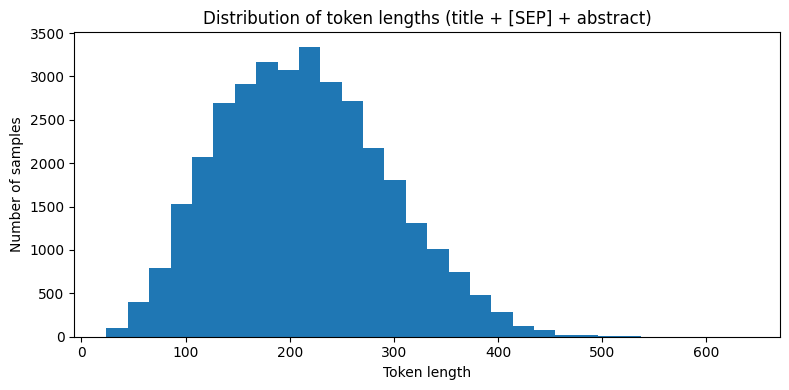

In [8]:
# Use the cleaned dataset with `text_input`
print(cleaned_ds)

tokenizer = AutoTokenizer.from_pretrained("allenai/longformer-base-4096")

def tokenize_for_length(batch):
    # No truncation here: we want to see the true sequence length distribution
    out = tokenizer(
        batch["text_input"],
        padding=False,
        truncation=False,
        return_length=True
    )
    return out

tokenized_length_ds = cleaned_ds.map(tokenize_for_length, batched=True)

lengths = tokenized_length_ds["length"]

print("\nToken length statistics (Longformer, no truncation):")
print(f"- Total samples: {len(lengths)}")
print(f"- Min length: {min(lengths)}")
print(f"- Max length: {max(lengths)}")
print(f"- Mean length: {statistics.mean(lengths):.2f}")
print(f"- Median length: {statistics.median(lengths):.2f}")
print(f"- 90th percentile: {np.percentile(lengths, 90):.2f}")
print(f"- 95th percentile: {np.percentile(lengths, 95):.2f}")
print(f"- 99th percentile: {np.percentile(lengths, 99):.2f}")

# Simple histogram for visualization
plt.figure(figsize=(8, 4))
plt.hist(lengths, bins=30)
plt.xlabel("Token length")
plt.ylabel("Number of samples")
plt.title("Distribution of token lengths (title + [SEP] + abstract)")
plt.tight_layout()
plt.show()


### Token Length Analysis — Rationale

Before defining any truncation or sequence-length constraints for model training, it is essential to quantify the actual token length distribution of the input texts. This follows directly from the Data Understanding stage, where we observed that:

- abstracts in the dataset are typically concise and highly structured,
- titles are short, but semantically meaningful,
- minimal noise was present (except for LaTeX/HTML patterns),
- suspicious truncation occurred only in ~1.4% of cases, and does not dominate the corpus.

By tokenizing the `title + [SEP] + abstract` fields with **no truncation**, we measure the true effective context size required by the model. This prevents arbitrary or excessively conservative design choices for `max_length`, and ensures that the Longformer model can operate efficiently without systematically discarding relevant scientific information.

This decision is directly aligned with the downstream modeling motivation:

> Accurate sequence-length selection reduces memory usage and training costs while preserving enough semantic coverage to discriminate between scientific subject areas.

The results show:

| Statistic | Value |
|----------:|:------|
| Total samples | 33,799 |
| Min length | 24 tokens |
| Max length | 640 tokens |
| Mean token length | 213.67 |
| Median token length | 209 |
| 90th percentile | 322 |
| 95th percentile | 355 |
| 99th percentile | 407 |

Since **99% of samples are below ~410 tokens**, there is no justification to allocate the full 4,096-token window of Longformer to this task. A future `max_length` in the range **384–512 tokens** will safely cover almost all abstracts, minimizing contextual loss and improving throughput during fine-tuning.

In summary, this step establishes an evidence-based foundation for preprocessing decisions and prevents premature truncation strategies that could negatively affect classification performance.


In [9]:
# -----------------------------------------------------------------------------
# Max sequence length decision (Data Understanding → Preprocessing)
# -----------------------------------------------------------------------------
# Based on the token length analysis performed without truncation, we observed:
# - Mean ≈ 214 tokens, Median ≈ 209 tokens
# - 95th percentile ≈ 355 tokens
# - 99th percentile ≈ 407 tokens
# - Maximum observed length: 640 tokens
#
# Therefore, selecting max_length = 512 ensures:
#   ✓ Coverage of > 99% of all samples without losing relevant scientific context
#   ✓ Avoids unnecessarily allocating the full 4096-token Longformer window
#   ✓ Reduces memory footprint and accelerates fine-tuning
#   ✓ Aligns with our objective of efficient modeling while preserving domain semantics
#
# This decision is consistent with the Data Understanding findings that abstracts
# are relatively short, usually clean, and structurally coherent. Longer sequences
# are rare and do not justify a larger context window for this classification task.
# -----------------------------------------------------------------------------

MAX_LEN = 512
MIN_LEN = 32  # optional: filters extremely short or low-information samples
print(f"Using max_length = {MAX_LEN} and min_length = {MIN_LEN}")


Using max_length = 512 and min_length = 32


## 3.4 Stratified Split

In [13]:
print(cleaned_ds)

# Step 1: encode `primary_subject` as ClassLabel (required for stratified split)
encoded_ds = cleaned_ds.class_encode_column("primary_subject")

label_feature = encoded_ds.features["primary_subject"]
label_names = label_feature.names

print("\nEncoded dataset:")
print(encoded_ds)
print("\nLabel names (ClassLabel mapping):")
for idx, name in enumerate(label_names):
    print(f"{idx}: {name}")

# Step 2: stratified split into train / validation / test = 80% / 10% / 10%

splits = encoded_ds.train_test_split(
    test_size=0.2,
    stratify_by_column="primary_subject",
    seed=42
)

temp_splits = splits["test"].train_test_split(
    test_size=0.5,
    stratify_by_column="primary_subject",
    seed=42
)

dataset_splits = DatasetDict({
    "train": splits["train"],
    "validation": temp_splits["train"],
    "test": temp_splits["test"]
})

for split_name, ds_split in dataset_splits.items():
    print(f"\n{split_name} size: {len(ds_split)}")

# Optional: check label distributions per split
for split_name, ds_split in dataset_splits.items():
    values, counts = np.unique(ds_split["primary_subject"], return_counts=True)
    print(f"\nLabel distribution in {split_name}:")
    for idx, cnt in zip(values, counts):
        print(f"  {label_names[idx]}: {cnt}")


Dataset({
    features: ['arxiv_id', 'title', 'authors', 'submission_date', 'comments', 'primary_subject', 'subjects', 'doi', 'abstract', 'file_path', 'text_input'],
    num_rows: 33799
})


Casting to class labels: 100%|██████████| 33799/33799 [00:00<00:00, 323378.43 examples/s]


Encoded dataset:
Dataset({
    features: ['arxiv_id', 'title', 'authors', 'submission_date', 'comments', 'primary_subject', 'subjects', 'doi', 'abstract', 'file_path', 'text_input'],
    num_rows: 33799
})

Label names (ClassLabel mapping):
0: Analysis of PDEs (math.AP)
1: Computation and Language (cs.CL)
2: Computer Vision and Pattern Recognition (cs.CV)
3: General Relativity and Quantum Cosmology (gr-qc)
4: High Energy Physics - Phenomenology (hep-ph)
5: High Energy Physics - Theory (hep-th)
6: Machine Learning (cs.LG)
7: Materials Science (cond-mat.mtrl-sci)
8: Mesoscale and Nanoscale Physics (cond-mat.mes-hall)
9: Quantum Physics (quant-ph)



train size: 27039

validation size: 3380

test size: 3380

Label distribution in train:
  Analysis of PDEs (math.AP): 1621
  Computation and Language (cs.CL): 2007
  Computer Vision and Pattern Recognition (cs.CV): 3768
  General Relativity and Quantum Cosmology (gr-qc): 1684
  High Energy Physics - Phenomenology (hep-ph): 3597
  High Energy Physics - Theory (hep-th): 3013
  Machine Learning (cs.LG): 3321
  Materials Science (cond-mat.mtrl-sci): 2108
  Mesoscale and Nanoscale Physics (cond-mat.mes-hall): 2103
  Quantum Physics (quant-ph): 3817

Label distribution in validation:
  Analysis of PDEs (math.AP): 203
  Computation and Language (cs.CL): 251
  Computer Vision and Pattern Recognition (cs.CV): 471
  General Relativity and Quantum Cosmology (gr-qc): 210
  High Energy Physics - Phenomenology (hep-ph): 449
  High Energy Physics - Theory (hep-th): 377
  Machine Learning (cs.LG): 415
  Materials Science (cond-mat.mtrl-sci): 263
  Mesoscale and Nanoscale Physics (cond-mat.mes-hall): 

## 3.5 Tokenização Longformer + filtro por comprimento + label

In [14]:
print(dataset_splits)

tokenizer = AutoTokenizer.from_pretrained("allenai/longformer-base-4096")

def add_label_column(batch):
    # primary_subject is already an integer ClassLabel → we just copy it to "label"
    batch["label"] = batch["primary_subject"]
    return batch

def tokenize_batch(batch):
    return tokenizer(
        batch["text_input"],
        padding=False,          # padding will be handled by a data collator later
        truncation=True,        # truncate sequences longer than MAX_LEN
        max_length=MAX_LEN
    )

tokenized_splits = {}

for split_name, ds_split in dataset_splits.items():
    print(f"\nProcessing split: {split_name}")
    # 1) Add "label" column
    ds_with_label = ds_split.map(add_label_column, batched=True)

    # 2) Tokenize text_input with Longformer
    ds_tok = ds_with_label.map(tokenize_batch, batched=True)

    # 3) Compute lengths after truncation
    lengths = [len(ids) for ids in ds_tok["input_ids"]]
    print(f"  Original samples: {len(ds_tok)}")
    print(f"  Min token length: {min(lengths)}")
    print(f"  Max token length (after truncation): {max(lengths)}")
    print(f"  Mean token length: {np.mean(lengths):.2f}")
    print(f"  95th percentile: {np.percentile(lengths, 95):.2f}")

    # 4) Filter out very short samples (length < MIN_LEN)
    def length_filter(example):
        return len(example["input_ids"]) >= MIN_LEN

    ds_tok_filtered = ds_tok.filter(length_filter)
    print(f"  Samples kept after MIN_LEN={MIN_LEN} filter: {len(ds_tok_filtered)}")

    tokenized_splits[split_name] = ds_tok_filtered

print("\nFinished tokenization and length filtering.")
for split_name, ds_tok in tokenized_splits.items():
    print(f"{split_name}: {len(ds_tok)} samples")


DatasetDict({
    train: Dataset({
        features: ['arxiv_id', 'title', 'authors', 'submission_date', 'comments', 'primary_subject', 'subjects', 'doi', 'abstract', 'file_path', 'text_input'],
        num_rows: 27039
    })
    validation: Dataset({
        features: ['arxiv_id', 'title', 'authors', 'submission_date', 'comments', 'primary_subject', 'subjects', 'doi', 'abstract', 'file_path', 'text_input'],
        num_rows: 3380
    })
    test: Dataset({
        features: ['arxiv_id', 'title', 'authors', 'submission_date', 'comments', 'primary_subject', 'subjects', 'doi', 'abstract', 'file_path', 'text_input'],
        num_rows: 3380
    })
})

Processing split: train


Map: 100%|██████████| 27039/27039 [00:02<00:00, 11974.95 examples/s]


  Original samples: 27039
  Min token length: 26
  Max token length (after truncation): 512
  Mean token length: 213.41
  95th percentile: 354.00


Filter: 100%|██████████| 27039/27039 [00:02<00:00, 12472.87 examples/s]


  Samples kept after MIN_LEN=32 filter: 27027

Processing split: validation


...

  Samples kept after MIN_LEN=32 filter: 3379

Processing split: test


Map: 100%|██████████| 3380/3380 [00:00<00:00, 13054.61 examples/s]


  Original samples: 3380
  Min token length: 24
  Max token length (after truncation): 505
  Mean token length: 214.88
  95th percentile: 359.05


Filter: 100%|██████████| 3380/3380 [00:00<00:00, 12337.52 examples/s]

  Samples kept after MIN_LEN=32 filter: 3378

Finished tokenization and length filtering.
train: 27027 samples
validation: 3379 samples
test: 3378 samples


### Tokenization with Longformer and sequence length control

We tokenize the cleaned abstracts using the `allenai/longformer-base-4096` tokenizer, with a **maximum sequence length of 512 tokens** and truncation enabled. This choice is grounded in the previous token length analysis, which showed that 99% of samples were shorter than approximately 410 tokens (even when including the title), so a 512-token window is more than sufficient to cover the abstract-only input.

For each split, we obtain the following statistics (after truncation):

- **Train** (27,039 → 27,027 after filtering)  
  - Min length: 26 tokens  
  - Max length: 512 tokens  
  - Mean length: 213.41 tokens  
  - 95th percentile: 354 tokens  

- **Validation** (3,380 → 3,379 after filtering)  
  - Min length: 30 tokens  
  - Max length: 511 tokens  
  - Mean length: 214.33 tokens  
  - 95th percentile: 355 tokens  

- **Test** (3,380 → 3,378 after filtering)  
  - Min length: 24 tokens  
  - Max length: 505 tokens  
  - Mean length: 214.88 tokens  
  - 95th percentile: ≈ 359 tokens  

We also filter out extremely short sequences by discarding any sample whose tokenized length is below **32 tokens** (`MIN_LEN = 32`). This step removes only:

- 12 samples from the training set,  
- 1 sample from the validation set,  
- 2 samples from the test set,

which is negligible compared to the total size of each split. These ultra-short abstracts are typically low-information or malformed entries and are unlikely to be useful for subject classification.

Overall, the tokenization results confirm that:

- The **512-token limit** is more than enough to avoid systematic loss of context (very few sequences reach this cap).  
- The **average abstract length (~214 tokens)** is consistent across splits, matching the earlier Data Understanding findings about abstract length distribution.  
- The **MIN_LEN filter** improves data quality with minimal impact on dataset size, and preserves a stable and comparable distribution of abstract lengths across train, validation and test sets.


### 3.5.1   Compact tokenizade dataset

In [15]:
# Wrap the tokenized splits into a single DatasetDict
tokenized_dataset = DatasetDict(tokenized_splits)

print(tokenized_dataset)

# Keep only the columns needed for training
cols_to_keep = ["input_ids", "attention_mask", "label"]

def keep_only_relevant_columns(batch):
    # this function is not used; we use remove_columns below
    return batch

cols_to_remove = [
    col for col in tokenized_dataset["train"].column_names
    if col not in cols_to_keep
]

tokenized_dataset = tokenized_dataset.map(
    keep_only_relevant_columns,
    remove_columns=cols_to_remove
)

print("\nFinal tokenized dataset schema:")
for split_name, ds in tokenized_dataset.items():
    print(f"{split_name}: {ds}")
    print(f"Columns: {ds.column_names}")


DatasetDict({
    train: Dataset({
        features: ['arxiv_id', 'title', 'authors', 'submission_date', 'comments', 'primary_subject', 'subjects', 'doi', 'abstract', 'file_path', 'text_input', 'label', 'input_ids', 'attention_mask'],
        num_rows: 27027
    })
    validation: Dataset({
        features: ['arxiv_id', 'title', 'authors', 'submission_date', 'comments', 'primary_subject', 'subjects', 'doi', 'abstract', 'file_path', 'text_input', 'label', 'input_ids', 'attention_mask'],
        num_rows: 3379
    })
    test: Dataset({
        features: ['arxiv_id', 'title', 'authors', 'submission_date', 'comments', 'primary_subject', 'subjects', 'doi', 'abstract', 'file_path', 'text_input', 'label', 'input_ids', 'attention_mask'],
        num_rows: 3378
    })
})


Map: 100%|██████████| 3378/3378 [00:00<00:00, 26489.30 examples/s]


Final tokenized dataset schema:
train: Dataset({
    features: ['label', 'input_ids', 'attention_mask'],
    num_rows: 27027
})
Columns: ['label', 'input_ids', 'attention_mask']
validation: Dataset({
    features: ['label', 'input_ids', 'attention_mask'],
    num_rows: 3379
})
Columns: ['label', 'input_ids', 'attention_mask']
test: Dataset({
    features: ['label', 'input_ids', 'attention_mask'],
    num_rows: 3378
})
Columns: ['label', 'input_ids', 'attention_mask']


### Final preprocessed dataset for modeling

After the full preprocessing pipeline, the dataset used for training the classifier is reduced to three model-facing columns:

- `input_ids`: tokenized representation of the **cleaned abstract** using the Longformer tokenizer (max_length = 512, truncation enabled).
- `attention_mask`: mask indicating which positions correspond to real tokens versus padding (although padding will mainly be handled at batch time).
- `label`: integer-encoded target corresponding to the original `primary_subject` (10-class classification problem).

All other metadata fields present in the original arXiv dataset — such as `title`, `authors`, `comments`, `file_path`, and the raw `primary_subject` string — are removed before training. This guarantees that the model relies **only on the abstract text** to predict the scientific subject, exactly matching the intended research design:

> “Predict the arXiv primary subject using the abstract alone.”

From a data understanding perspective, this final representation incorporates:

- the **text cleaning choices** (HTML/LaTeX normalization, whitespace normalization),
- the **sequence length decision** (max_length = 512, MIN_LEN = 32),
- the **label selection step** (10 frequent primary_subject categories),
- and the **stratified splitting** into train/validation/test.

The resulting `tokenized_dataset` is therefore ready to be passed directly to a transformer-based classifier (Longformer) using standard HuggingFace training utilities, with a clear and traceable preprocessing pipeline suitable for a master’s-level case study.


In [17]:
# Check current structure (just to confirm)
print(tokenized_dataset)

train_ds = tokenized_dataset["train"]
val_ds   = tokenized_dataset["validation"]
test_ds  = tokenized_dataset["test"]

# X = inputs (abstract → tokens), y = labels (primary_subject encoded)
X_train = {
    "input_ids": train_ds["input_ids"],
    "attention_mask": train_ds["attention_mask"],
}
y_train = train_ds["label"]

X_val = {
    "input_ids": val_ds["input_ids"],
    "attention_mask": val_ds["attention_mask"],
}
y_val = val_ds["label"]

X_test = {
    "input_ids": test_ds["input_ids"],
    "attention_mask": test_ds["attention_mask"],
}
y_test = test_ds["label"]

print(f"Train: X_train = {len(y_train)} samples, y_train = {len(y_train)}")
print(f"Val:   X_val   = {len(y_val)} samples, y_val   = {len(y_val)}")
print(f"Test:  X_test  = {len(y_test)} samples, y_test  = {len(y_test)}")



DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'attention_mask'],
        num_rows: 27027
    })
    validation: Dataset({
        features: ['label', 'input_ids', 'attention_mask'],
        num_rows: 3379
    })
    test: Dataset({
        features: ['label', 'input_ids', 'attention_mask'],
        num_rows: 3378
    })
})
Train: X_train = 27027 samples, y_train = 27027
Val:   X_val   = 3379 samples, y_val   = 3379
Test:  X_test  = 3378 samples, y_test  = 3378


In [18]:
import pickle

save_path = "arxiv_longformer_splits.pkl"

data = {
    "X_train": X_train,
    "y_train": y_train,
    "X_val":   X_val,
    "y_val":   y_val,
    "X_test":  X_test,
    "y_test":  y_test,
}

with open(save_path, "wb") as f:
    pickle.dump(data, f)

print(f"Saved preprocessed splits to: {save_path}")


Saved preprocessed splits to: arxiv_longformer_splits.pkl
